In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/cleaned_support_tickets.csv")

print("Cleaned dataset loaded successfully!")

Cleaned dataset loaded successfully!


In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 47837
Columns: 3


In [4]:
# Check ticket category distribution

df["Topic_group"].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

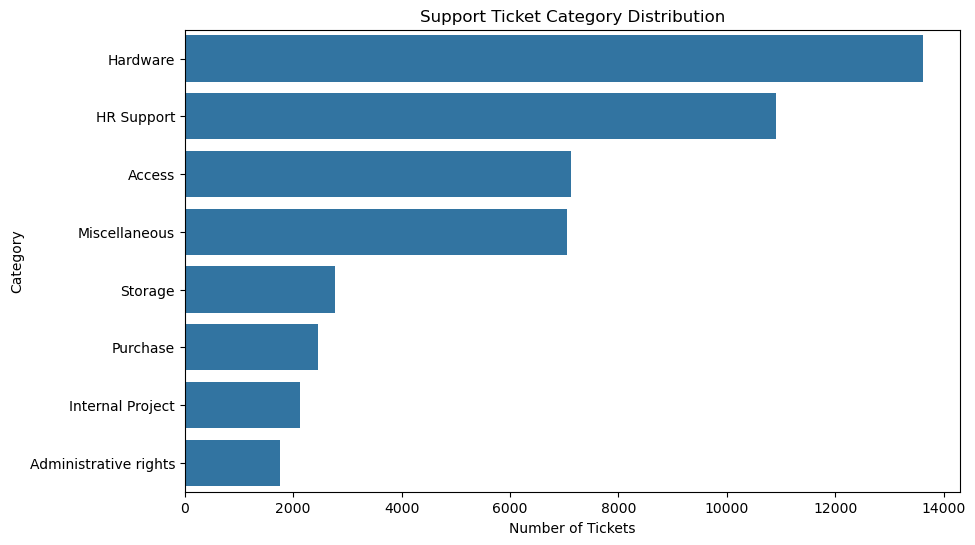

In [5]:
# Plot ticket category distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Topic_group",
    order=df["Topic_group"].value_counts().index
)

plt.title("Support Ticket Category Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()

In [6]:
# Check ticket text length

df["text_length"] = df["Document"].astype(str).str.len()

df["text_length"].describe()

count    47837.000000
mean       291.881263
std        388.171200
min          7.000000
25%        110.000000
50%        175.000000
75%        304.000000
max       7015.000000
Name: text_length, dtype: float64

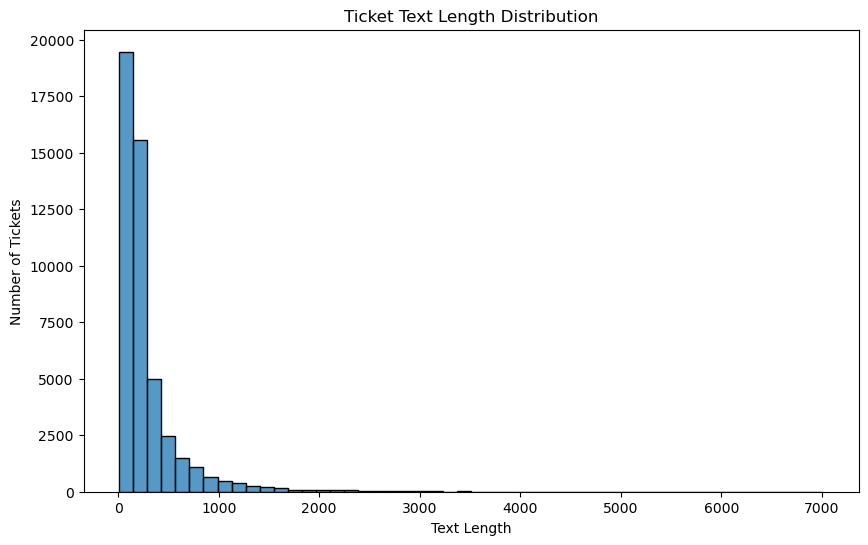

In [7]:
# Plot ticket text length distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["text_length"],
    bins=50
)

plt.title("Ticket Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Number of Tickets")

plt.show()

In [8]:
# Find shortest and longest tickets

print("Shortest ticket:")
print(df.loc[df["text_length"].idxmin(), "Document"])

print("\nLongest ticket:")
print(df.loc[df["text_length"].idxmax(), "Document"])

Shortest ticket:
open si

Longest ticket:
for re hi after talking mo looks link function best positioned make change please add routes existing interconnect via added routes which carried across then over connect believe needs done add route also route also add dynamic routing main please hesitate come back thanks infrastructure architect ext october re thanks mo mo please liaise going forward regards infrastructure programme upcoming leave st december october re good morning gents mo taking today looks added route which mean add routing well mo cr change mo please update after taken thanks infrastructure architect ext october re hi looking once routing has setup tested successfully please configuration resolved test prior regards infrastructure programme upcoming leave st december october re hi done work unable connect saying cannot traffic copy thread anybody also include based test seems resolve suspicion routing attached hit routing then connect well thanks number re hi let work sc

In [9]:
# Check average ticket length by category

df.groupby("Topic_group")["text_length"].mean().sort_values(ascending=False)

Topic_group
Hardware                 375.408240
Administrative rights    339.182955
Miscellaneous            286.876487
Internal Project         250.317603
HR Support               249.252313
Purchase                 244.642857
Access                   242.338667
Storage                  233.347137
Name: text_length, dtype: float64

In [10]:
# Display sample tickets from each category

for category in df["Topic_group"].unique():
    print("\nCATEGORY:", category)
    print(df[df["Topic_group"] == category]["Document"].head(2).to_list())


CATEGORY: Hardware
['connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead', 'requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug']

CATEGORY: Access
['work experience user work experience user hi work experience student coming next his name much appreciate him duration thank', 'reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly

In [11]:
# Save EDA dataset with text length

df.to_csv(
    "../data/cleaned_support_tickets.csv",
    index=False
)

print("EDA analysis completed!")

EDA analysis completed!


In [12]:
# Check category percentages

category_percentage = (
    df["Topic_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

Topic_group
Hardware                 28.47
HR Support               22.82
Access                   14.89
Miscellaneous            14.76
Storage                   5.81
Purchase                  5.15
Internal Project          4.43
Administrative rights     3.68
Name: proportion, dtype: float64

In [13]:
# Check whether categories are balanced

print("Largest category:", df["Topic_group"].value_counts().max())
print("Smallest category:", df["Topic_group"].value_counts().min())

Largest category: 13617
Smallest category: 1760


In [14]:
# Check text statistics by category

df.groupby("Topic_group")["text_length"].agg(
    ["count", "mean", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,min,max
Topic_group,,,,
Hardware,13617,375.408240,7,7015
Administrative rights,1760,339.182955,21,6880
Miscellaneous,7060,286.876487,7,6912
Internal Project,2119,250.317603,25,5206
HR Support,10915,249.252313,13,5595
Purchase,2464,244.642857,16,2827
Access,7125,242.338667,15,6363
Storage,2777,233.347137,27,3021


In [15]:
# Check for extremely short tickets

print(
    "Tickets with less than 10 characters:",
    (df["text_length"] < 10).sum()
)

Tickets with less than 10 characters: 3
